<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/Autograd_in_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is Autograd**

Autograd is a core component of PyTorch that provides automatic differentiation for tensor operations. It enables gradient computation, which is essential for training machine learning models using optimization algorithms like gradient descent.
Examples
$y = x^2$
$y = x^2, \quad z = \sin(y)
$Neural network


Autograd Kya Hai?

Asan alfaz mein kahein to Autograd PyTorch ka wo engine hai jo math ke mushkil calculations (jinhein differentiation kehte hain) khud-ba-khud kar leta hai.Automatic Differentiation: Machine learning mein jab hum model ko train karte hain, to hamein "Gradients" nikalne parte hain takay model apni ghaltiyon se seekh sakay. Autograd ye kaam automatic kar deta hai, aapko manually lambay formulas solve nahi karne parte.

Examples ki wazahat:

1. Pehli example ($y = x^2$) ek sadha formula hai.2. Dusri example mein ek ke andar dusra function hai ($z = \sin(y)$). Autograd in dono ko aapas mein jorr kar calculus ka "Chain Rule" khud apply kar deta hai.

Neural Network: Ek neural network mein hazaron aisi equations hoti hain. Autograd un sab ka hisab rakhta hai takay Gradient Descent ke zariye aapka model behtar perform kar sakay.Kya

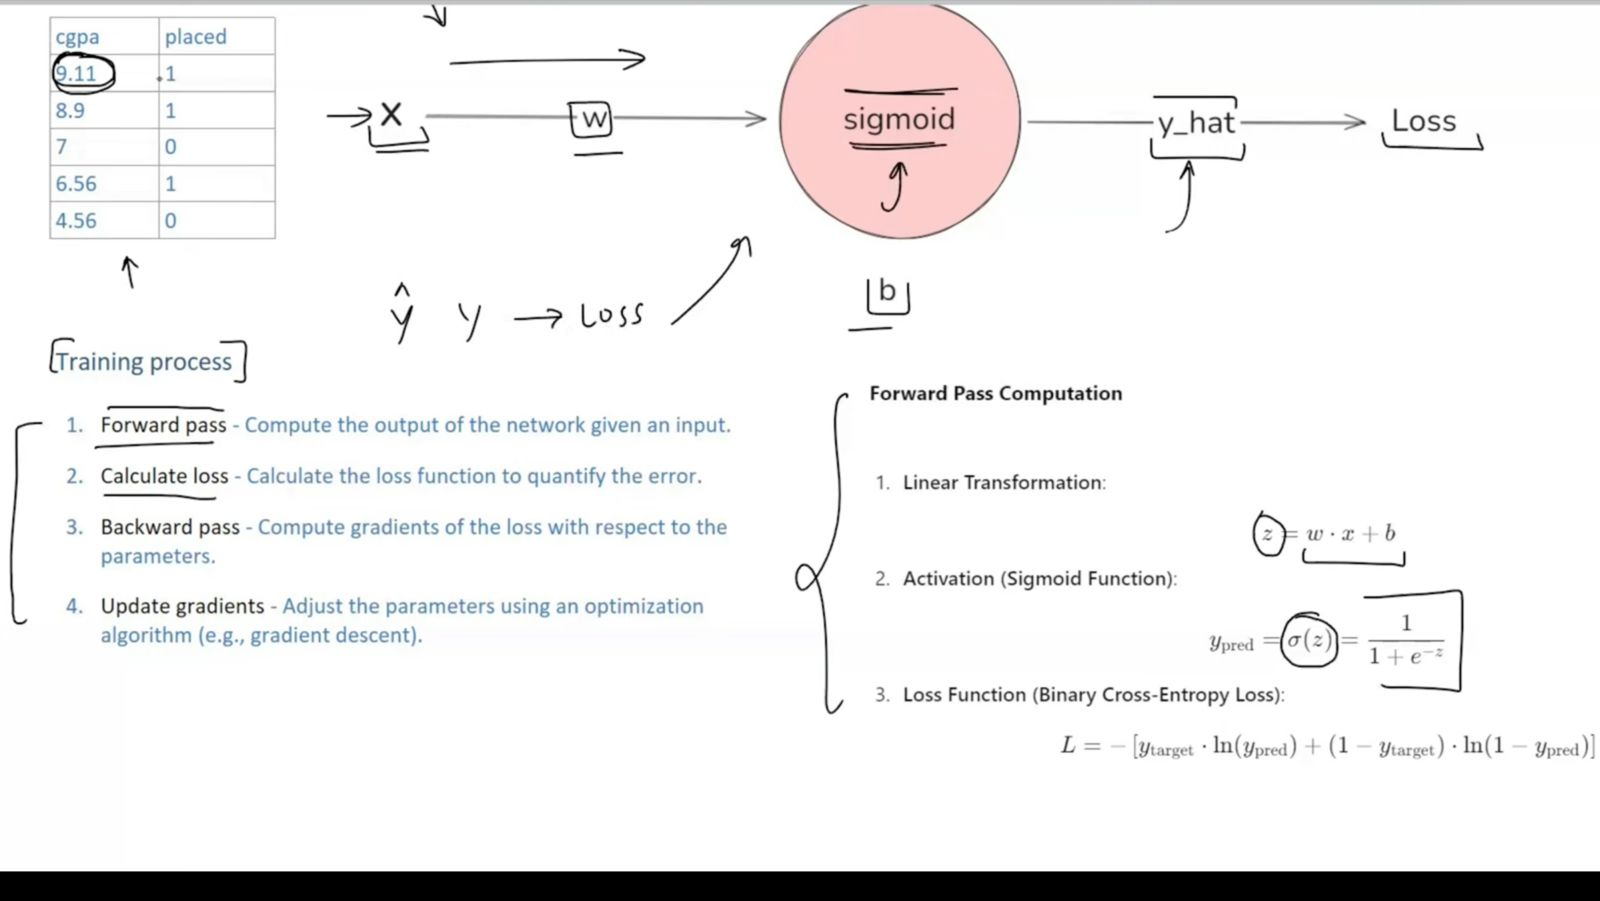

Loss function kya karta hai?

Loss function model ki mistake measure karta hai.

Agar prediction actual answer ke qareeb hai, loss low hota hai.
Agar prediction actual answer se door hai, loss high hota hai.

Binary classification mein hum usually use karte hain:

Binary Cross Entropy Loss


L = - [ y * log(ŷ) + (1 - y) * log(1 - ŷ) ]

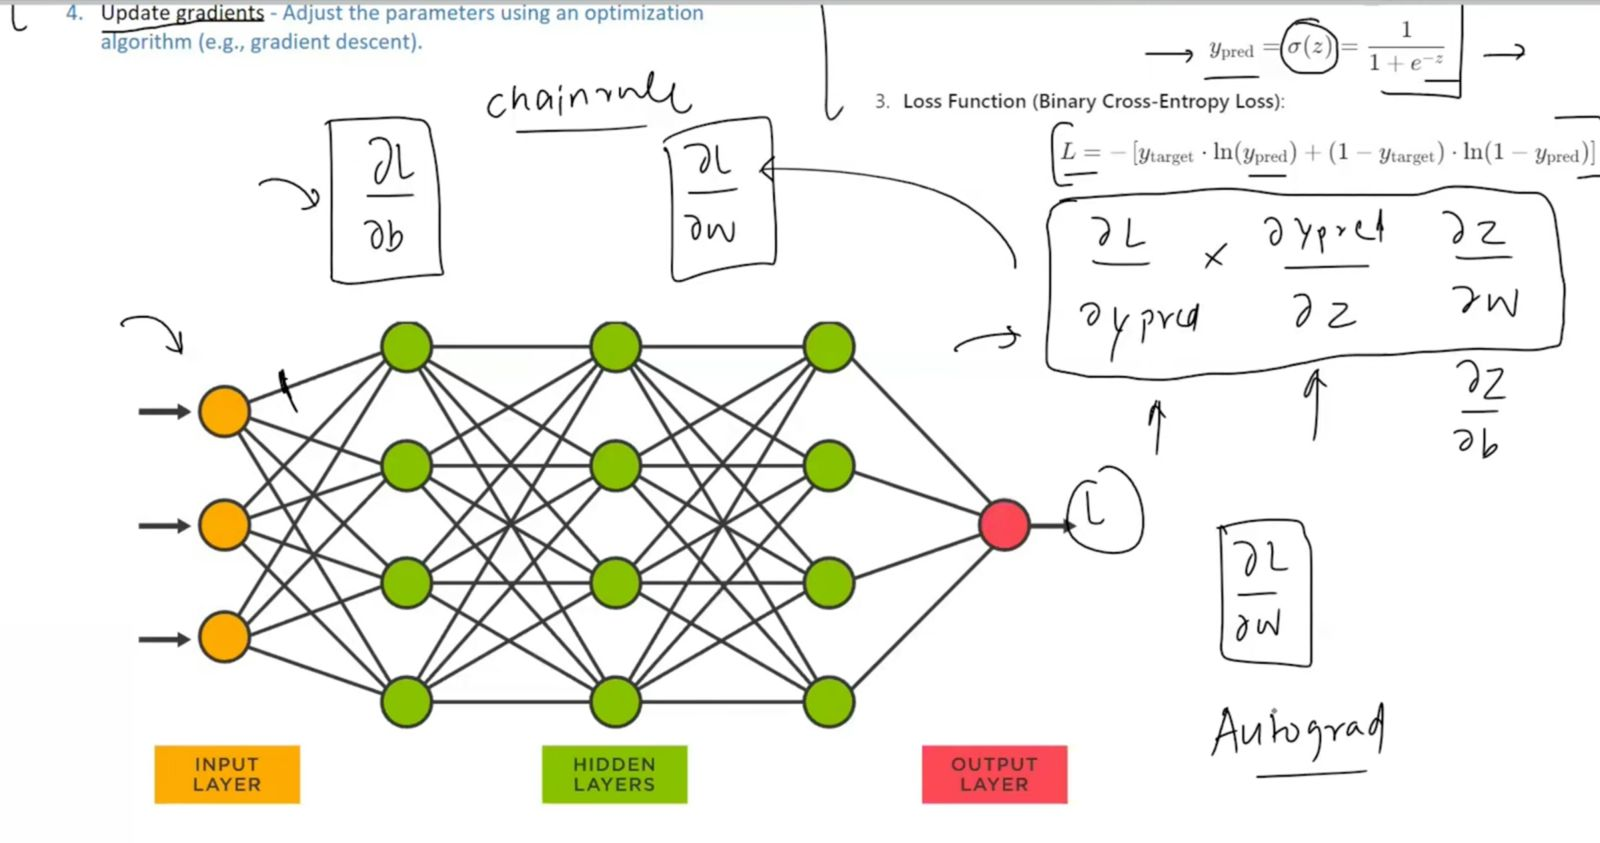

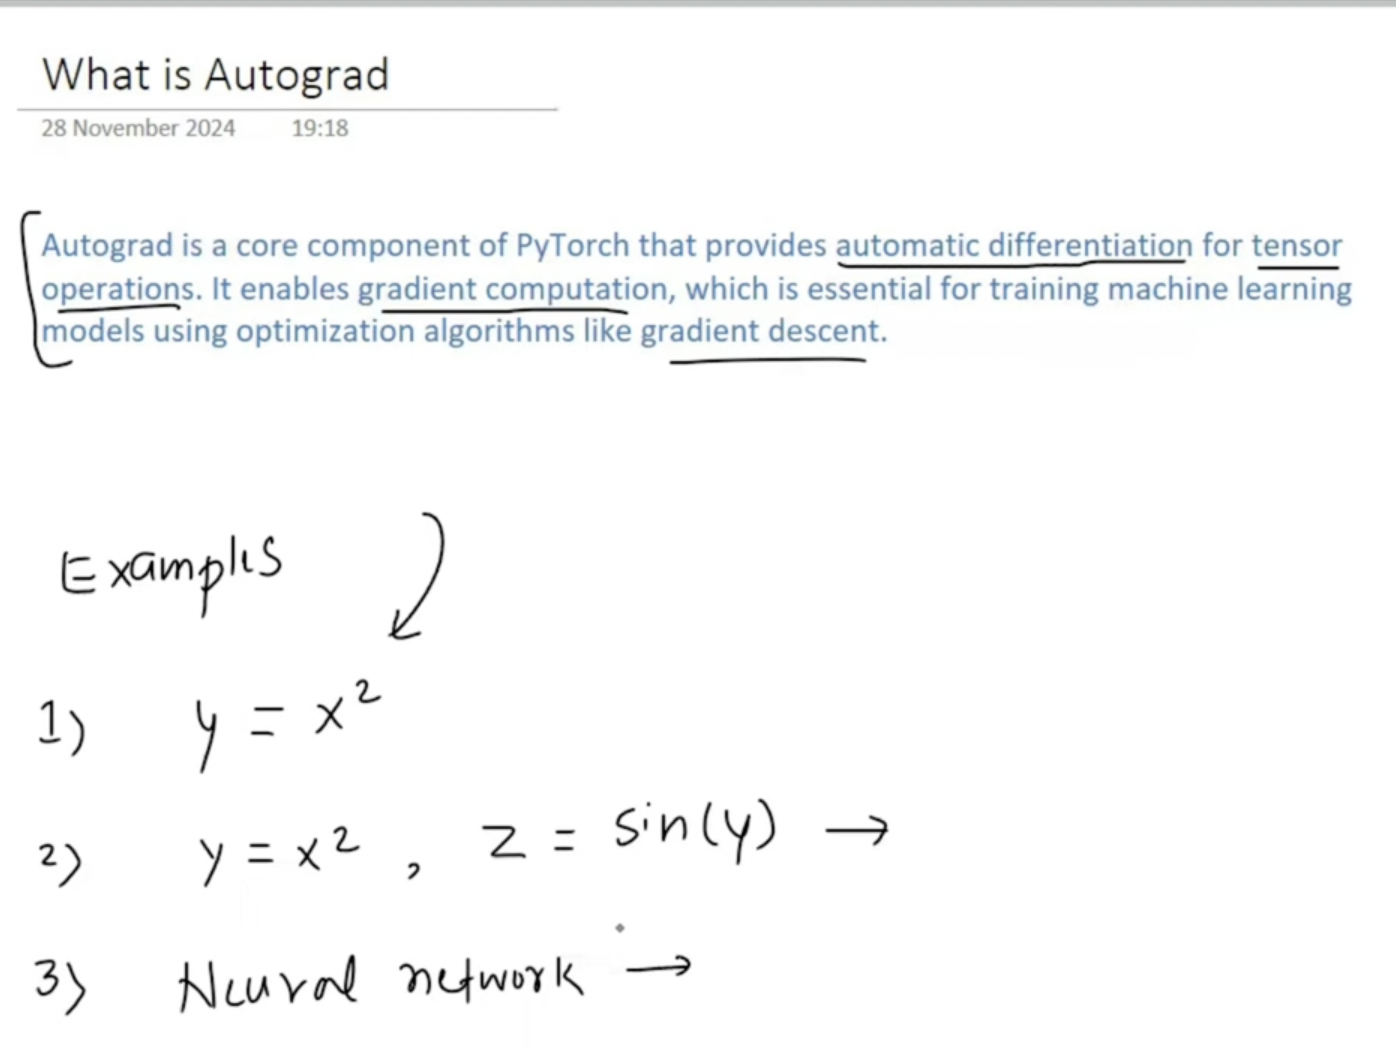

In [2]:
import torch


In [3]:
x = torch.tensor(3.0 ,requires_grad=True)

In [4]:
y = x**2

In [5]:
x

tensor(3., requires_grad=True)

In [6]:
y

tensor(9., grad_fn=<PowBackward0>)

In [7]:
y.backward()

In [8]:
x.grad

tensor(6.)







Is code mein hum PyTorch ko use kar ke ek simple math equation ka derivative (gradient) nikal rahe hain.
1. Tensor Creation x = torch.tensor(3.0, requires_grad=True)Yahan humne $x$ ki value 3.0 rakhi hai. requires_grad=True ka matlab hai ke hum PyTorch ko bata rahe hain ke "bhai, is variable ka hisab rakhna kyunke baad mein hamein iska gradient chahiye."
2. The Equation y = x**2Yahan humne function banaya: $y = x^2$. Jab $x = 3$ hoga, to $y = 3^2 = 9$. Aap output mein dekh sakte hain ke y ki value 9 aayi hai.
3. Backward Pass (The Magic)y.backward()Ye sab se important line hai. Jab hum .backward() call karte hain, to PyTorch piche ki taraf (backwards) jata hai aur check karta hai ke $y$ mein tabdeeli aane se $x$ par kya asar para. Mathematics mein iska derivative hota hai:$$\frac{dy}{dx} = 2x$$
4. Result (Gradient) x.grad Ab humne check kiya ke $x$ ka gradient kya aya.Chunkay formula $2x$ tha, aur hamari $x$ ki value 3 thi, to:$$2 \times 3 = 6$$Isi liye output mein tensor(6.) nazar aa raha hai.Summary Diagram ExplanationComputational graph mein do steps hote hain:Forward Pass: $x$ (3) se $y$ (9) tak jana.Backward Pass: $y$ se wapas $x$ ki taraf aana derivative lete hue takay hamein gradient (6) mil sakay.



---

\

In [9]:
x = torch.tensor(3.0 , requires_grad=True)


In [10]:
y = x**2

In [11]:
z = torch.sin(y)

In [12]:
x

tensor(3., requires_grad=True)

In [13]:
y

tensor(9., grad_fn=<PowBackward0>)

In [14]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [15]:
z.backward()


In [16]:
x.grad

tensor(-5.4668)

In [17]:
y.grad

/tmp/ipykernel_1712/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  y.grad


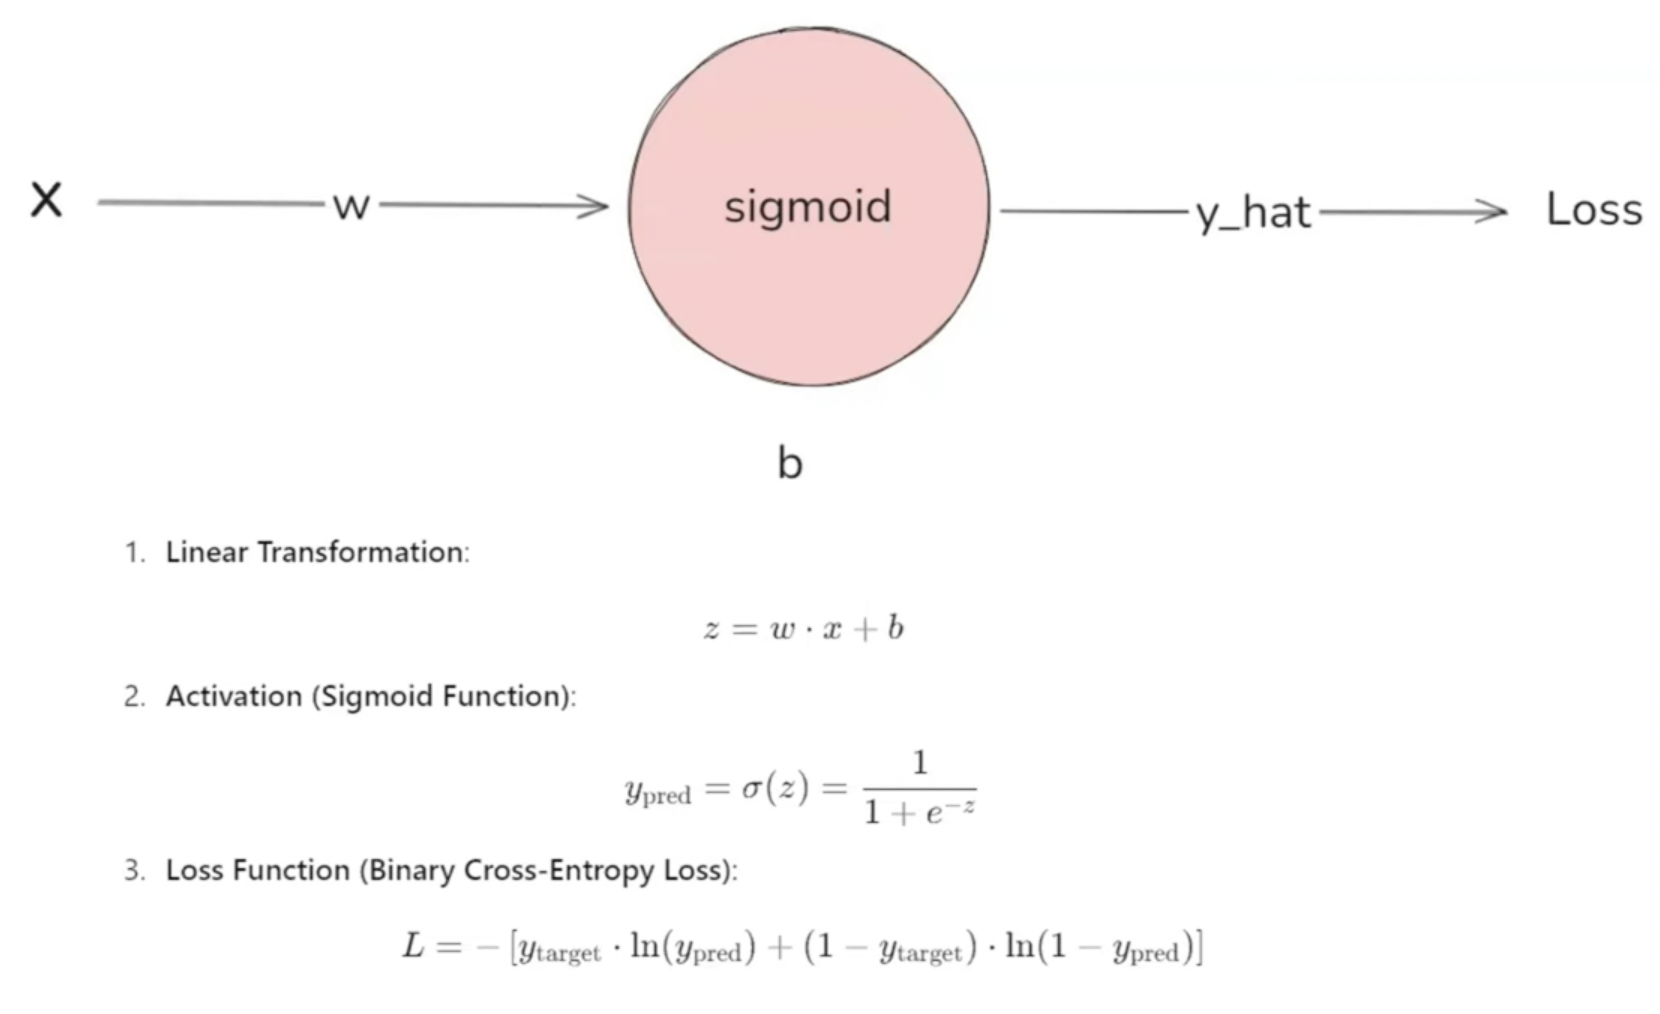

In [18]:
x = torch.tensor(6.9)
y = torch.tensor(0.0)

In [19]:
w = torch.tensor(1.0 , requires_grad=True)
b = torch.tensor(0.0 , requires_grad=True)

In [20]:
w

tensor(1., requires_grad=True)

In [21]:
b

tensor(0., requires_grad=True)

In [22]:
z = w*x + b

In [23]:
z # z ki value jo i hai us ko hum raw tn logit kehty hn is k bad hum z ki value ka sigmoid nikaly gay jisy hhum prediction kehty hn

tensor(6.9000, grad_fn=<AddBackward0>)

In [24]:
y_pred  = torch.sigmoid(z)
y_pred

tensor(0.9990, grad_fn=<SigmoidBackward0>)

In [25]:
#PyTorch docs mein torch.nn.functional ke andar activation functions,
#linear functions, dropout, distance functions, aur loss functions jaise binary_cross_entropy, cross_entropy, mse_loss etc.
# listed hain. binary_cross_entropy input probabilities aur target ke beech BCE loss compute karta hai.

import torch.nn.functional as F

loss = F.binary_cross_entropy(y_pred, y)
loss

tensor(6.9010, grad_fn=<BinaryCrossEntropyBackward0>)

In [27]:
l = -(y*torch.log(y_pred) + (1-y)*torch.log(1-y_pred))
l

tensor(6.9010, grad_fn=<NegBackward0>)